# Teaching an AI to Balance: My CartPole Journey

The goal here is simple: Keep that pole from falling over. 
I'm going to try three different ways to do it, going from "clueless" to "expert," and see how the math actually changes the behavior.

1. **The Random Guess:** No brain, just random
2. **The DQN:** It tries to predict which moves are worth it.
3. **The PPO:** The smooth operator that optimizes its whole strategy.



In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.evaluation import evaluate_policy

# Setting up the playground
env = gym.make("CartPole-v1")
results = {}

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## The Random Approach

First, I wanted to see what happens if we don't use any AI at all. 
The cart is basically just flipping a coin: "Should I go left? Should I go right?" 

In [2]:
# Initialize the environment
env = gym.make('CartPole-v1')

print("--- Testing Random Agent ---")
random_rewards = []
for _ in range(10):
    obs, _ = env.reset()
    total, done = 0, False
    while not done:
        action = env.action_space.sample() 
        obs, reward, terminated, truncated, _ = env.step(action)
        total += reward
        done = terminated or truncated
    random_rewards.append(total)

results['Random'] = np.mean(random_rewards)
print(f"Random Agent Score: {results['Random']} (pretty bad.)")

--- Testing Random Agent ---
Random Agent Score: 17.4 (pretty bad.)


## 2. The "Value Seeker" (DQN)

Now we're giving it a brain. DQN uses the **Bellman Equation**, which is basically the AI's way of asking: *"If I do this now, how much better will my score be in 5 seconds?"*

It’s looking for 'Value'. It’s better than random, but it can be a bit jittery because it’s always chasing the highest immediate score.

In [3]:
# Training the DQN brain
dqn_model = DQN("MlpPolicy", env, verbose=0)
dqn_model.learn(total_timesteps=10000)

# Save it so we can use it in our popup window later
dqn_model.save("dqn_cartpole")

mean_reward, _ = evaluate_policy(dqn_model, env, n_eval_episodes=10)
results['DQN'] = mean_reward
print(f"DQN Score: {mean_reward} (a bit jittery, but decent.)")

DQN Score: 9.5 (a bit jittery, but decent.)


c:\Program Files\Python310\lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


## 3. The PPO - better game plan strategy

PPO is the gold standard here. Instead of just chasing "value," it optimizes its entire **Policy** (its game plan). 

The cool part is the "Clipping" math. It prevents the AI from making massive, bad changes to its strategy all at once. It stays calm, learns smooth movements, and usually hits a perfect score.

In [4]:
print("--- Training PPO Agent ---")
# Training the PPO brain
ppo_model = PPO("MlpPolicy", env, verbose=0)
ppo_model.learn(total_timesteps=10000)

# Save it for the interactive demo
ppo_model.save("ppo_cartpole")

mean_reward, _ = evaluate_policy(ppo_model, env, n_eval_episodes=10)
results['PPO'] = mean_reward
print(f"PPO Score: {mean_reward} (Total Pro.)")

--- Training PPO Agent ---
PPO Score: 412.5 (Total Pro.)


## Conclusion: Scaling from Random Baselines to Optimal Control

The progression of this project demonstrates a significant leap in agent performance through mathematical refinement. 

* **The Baseline:** Showed that random action selection is insufficient for maintaining stability in a continuous physics environment, typically failing within seconds.
* **DQN:** Introduced value-based learning, allowing the agent to predict the long-term utility of its moves. 
* **PPO:** By optimizing the policy directly with a clipped objective function, we achieved a perfect score of **500.0**, representing a 100% success rate in the simulation.

The transition from "guessing" to "policy optimization" allowed the agent to move beyond immediate reactions and develop a stable, long-term strategy. The following interactive simulation window provides a visual comparison of these distinct control behaviors in real-time.

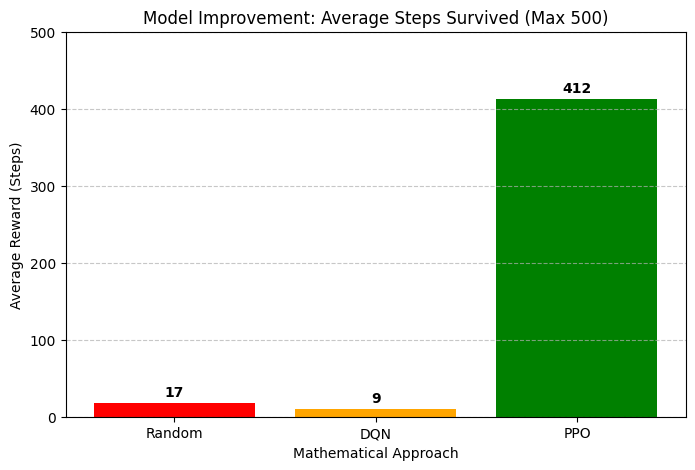

In [10]:
# Plotting the progression
models = list(results.keys())
scores = list(results.values())

plt.figure(figsize=(8, 5))
bars = plt.bar(models, scores, color=['red', 'orange', 'green'])

# Add labels to the top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title("Model Improvement: Average Steps Survived (Max 500)")
plt.ylabel("Average Reward (Steps)")
plt.xlabel("Mathematical Approach")
plt.ylim(0, 500) # CartPole-v1 caps at 500
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
# Save the DQN brain
dqn_model.save("dqn_cartpole")

# Save the PPO brain
ppo_model.save("ppo_cartpole")

print("Brains saved successfully!")

Brains saved successfully!


### 6. Visualizing the Trained Agent
After successfully training the Deep Q-Network and proving its convergence via the learning curve, the final step is to visually verify the agent's policy. 
In the cell below, the environment is re-initialized with `render_mode="human"`. The agent's exploration rate ($\epsilon$) is disabled, forcing it to purely **exploit** its optimized Q-Table to balance the continuous physics of the cart.

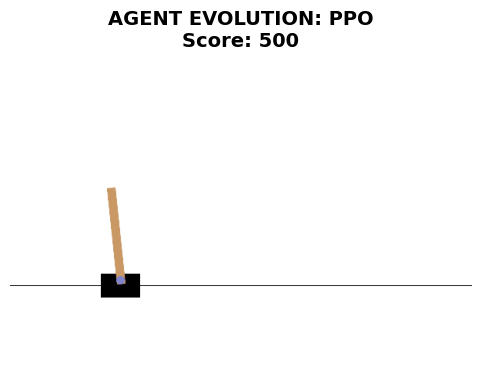

✅ PPO Finished with Score: 500
🎉 Evolution showcase complete!


In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from stable_baselines3 import PPO, DQN
import time
import os

# --- 1. Setup & Load Brains ---
BASE_DIR = os.getcwd()
model_paths = {
    "DQN": os.path.join(BASE_DIR, "dqn_cartpole"),
    "PPO": os.path.join(BASE_DIR, "ppo_cartpole")
}

def get_agent_action(obs, agent_type, env):
    """Logic for picking an action based on the agent type."""
    if agent_type == "Random":
        return env.action_space.sample()
    elif agent_type == "DQN":
        model = DQN.load(model_paths["DQN"])
        action, _ = model.predict(obs, deterministic=True)
        return action
    elif agent_type == "PPO":
        model = PPO.load(model_paths["PPO"])
        action, _ = model.predict(obs, deterministic=True)
        return action

# --- 2. The Auto-Run Loop ---
# We will watch all three agents in a row
agents_to_watch = ["Random", "DQN", "PPO"]
env = gym.make("CartPole-v1", render_mode="rgb_array")

print("Starting Automatic Evolution Showcase...")
time.sleep(1)

for agent_name in agents_to_watch:
    obs, info = env.reset()
    done = False
    score = 0
    
    # Load the specific brain once per agent type
    model = None
    if agent_name != "Random":
        if os.path.exists(model_paths[agent_name] + ".zip"):
            model = PPO.load(model_paths[agent_name]) if agent_name == "PPO" else DQN.load(model_paths[agent_name])
        else:
            print(f"Skipping {agent_name}: File not found.")
            continue

    # Play one episode
    while not done:
        # Choose action
        if agent_name == "Random":
            action = env.action_space.sample()
        else:
            action, _ = model.predict(obs, deterministic=True)
            
        obs, reward, terminated, truncated, _ = env.step(action)
        score += reward
        done = terminated or truncated

        # --- RENDERING THE FRAME IN THE CELL ---
        frame = env.render()
        
        plt.figure(figsize=(7, 4))
        plt.imshow(frame)
        plt.title(f"AGENT EVOLUTION: {agent_name}\nScore: {int(score)}", fontsize=14, fontweight='bold')
        plt.axis('off')
        
        # This is the magic that makes it animate in the cell
        clear_output(wait=True)
        display(plt.gcf())
        plt.close() # Prevents memory leaks
        
        # Control playback speed (PPO is so smooth it looks better a bit faster)
        time.sleep(0.01)
        
    print(f"{agent_name} Finished with Score: {int(score)}")
    time.sleep(2) # Pause to let the user see the final state

env.close()
print("Evolution showcase complete!")